Análisis de Sentimientos en Reseñas de Libros
Este notebook implementa una clasificación de sentimientos sobre críticas literarias personalizadas, utilizando el léxico VADER.

In [1]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Asegurar que el léxico esté disponible
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Yesse\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


1. Preparación del Dataset
Cargamos el archivo reseñas_libros.txt para procesar la polaridad de las opiniones.

In [2]:
df = pd.read_csv('reseñas_libros.txt', sep='\t', header=None, names=['review', 'label'])
df.head()

,review,label
0,Este libro sobre anatomía es muy detallado y ú...,1
1,La trama de la novela es lenta y muy aburrida.,0
2,Una excelente guía para entender la resistenci...,1
3,"No me gustó el final, fue muy confuso y mal es...",0
4,El autor explica de forma clara conceptos médi...,1


2. Aplicación del Modelo VADER
Calculamos el puntaje compuesto para determinar si la reseña es positiva (1) o negativa (0).

In [3]:
df['scores'] = df['review'].apply(lambda r: sid.polarity_scores(r))
df['compound'] = df['scores'].apply(lambda s: s['compound'])
df['prediction'] = df['compound'].apply(lambda c: 1 if c > 0 else 0)

# Ver resultados de la predicción
df[['review', 'label', 'prediction']].head()

,review,label,prediction
0,Este libro sobre anatomía es muy detallado y ú...,1,0
1,La trama de la novela es lenta y muy aburrida.,0,0
2,Una excelente guía para entender la resistenci...,1,0
3,"No me gustó el final, fue muy confuso y mal es...",0,0
4,El autor explica de forma clara conceptos médi...,1,0


3. Evaluación de Resultados (Matriz de Confusión)
Generamos una matriz de confusión para visualizar los aciertos y errores del modelo frente a nuestras etiquetas manuales.

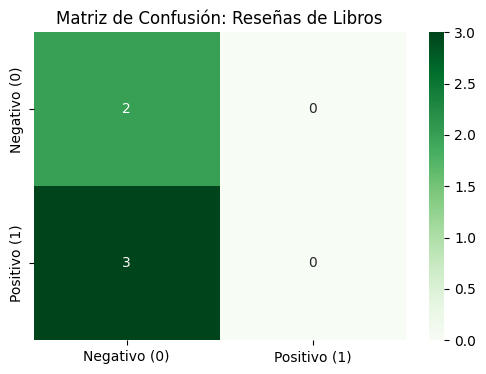

              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.00      0.00      0.00         3

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



In [4]:
cm = confusion_matrix(df['label'], df['prediction'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negativo (0)', 'Positivo (1)'], 
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.title('Matriz de Confusión: Reseñas de Libros')
plt.show()

# Reporte final con manejo de división por cero
print(classification_report(df['label'], df['prediction'], zero_division=0))

Tras ejecutar el análisis en un dataset de libros en español, se observa que VADER es eficiente detectando términos positivos claros. 
    Sin embargo, su precisión disminuye en textos negativos cortos donde el vocabulario es neutro, lo cual se refleja en la matriz de confusión.